# 09 — Model Diagnostics (no re-run needed)

Post-processing tests to evaluate the v01 model without re-running:
1. **Datum bias offset** — compute mean bias and apply correction to see amplitude fit
2. **Drying check** — verify if BS and AE stations go dry during simulation
3. **Central points from map.nc** — extract time series at deeper central lagoon locations for 3D structure analysis

## 1. Imports and paths

In [21]:
%matplotlib inline
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import xarray as xr
import xugrid as xu

project_root = Path(r'F:\StagnoneDT')
model_dir = project_root / 'model' / 'dflowfm'
output_dir = model_dir / 'output'
processed_dir = project_root / 'data' / 'processed'
figures_dir = project_root / 'figures'

his_file = output_dir / 'Stagnone_dxy01_15m_his.nc'
map_file = output_dir / 'Stagnone_dxy01_15m_map.nc'

## 2. Bias offset analysis (datum correction)

If there's a systematic offset, compute mean bias per station, apply correction, and re-evaluate amplitude fit.

In [22]:
# Load his file and in-situ data
ds_his = xr.open_dataset(str(his_file))
station_names = [s.decode() if isinstance(s, bytes) else str(s) for s in ds_his.station_name.values]
station_names = [n.strip() for n in station_names]

# Find indices
def find_station(target):
    for i, n in enumerate(station_names):
        if target.lower() in n.lower():
            return i
    return None

idx = {
    'BocaNord': find_station('BocaNord'),
    'BocaSud': find_station('BocaSud'),
    'AltaVilaEst': find_station('AltaVilaEst') or find_station('AltavilaEst') or find_station('Altavila'),
}
print('Station indices:', idx)

# Load observations
obs_files = {
    'BocaNord': 'wl_BocaNord_10min_UTC.csv',
    'BocaSud': 'wl_BocaSud_10min_UTC.csv',
    'AltaVilaEst': 'wl_AltavilaEst_10min_UTC.csv',
}

comparisons = {}
for name, fname in obs_files.items():
    if idx[name] is None:
        continue
    model_wl = ds_his.waterlevel.isel(station=idx[name]).to_pandas()
    model_wl.name = 'wl_model'
    obs = pd.read_csv(str(processed_dir / fname), index_col=0, parse_dates=True)
    obs.columns = ['wl_obs']
    df = pd.concat([model_wl, obs['wl_obs']], axis=1).dropna()
    # Skip spin-up
    spin_end = df.index[0] + pd.Timedelta(hours=12)
    df = df[df.index >= spin_end].copy()
    df['bias'] = df['wl_model'] - df['wl_obs']
    comparisons[name] = df

# Compute bias per station
print('\nMean bias (model - obs):')
biases = {}
for name, df in comparisons.items():
    b = df['bias'].mean()
    biases[name] = b
    print(f'  {name:12s}: bias = {b:+.4f} m')

# Average bias for single-offset correction
avg_bias = np.mean(list(biases.values()))
print(f'\n  Average bias across stations: {avg_bias:+.4f} m')
print(f'  Recommendation: subtract this from model output or add to WL boundary offset')

Station indices: {'BocaNord': 15, 'BocaSud': 16, 'AltaVilaEst': 14}

Mean bias (model - obs):
  BocaNord    : bias = -0.4323 m
  BocaSud     : bias = -0.4505 m
  AltaVilaEst : bias = -0.3798 m

  Average bias across stations: -0.4208 m
  Recommendation: subtract this from model output or add to WL boundary offset


Station        RMSE_raw  RMSE_corr    d_raw   d_corr     offset
--------------------------------------------------------------
BocaNord         0.4372     0.0656    0.224    0.860    -0.4323
BocaSud          0.4517     0.0338    0.165    0.881    -0.4505
AltaVilaEst      0.3823     0.0432    0.209    0.835    -0.3798


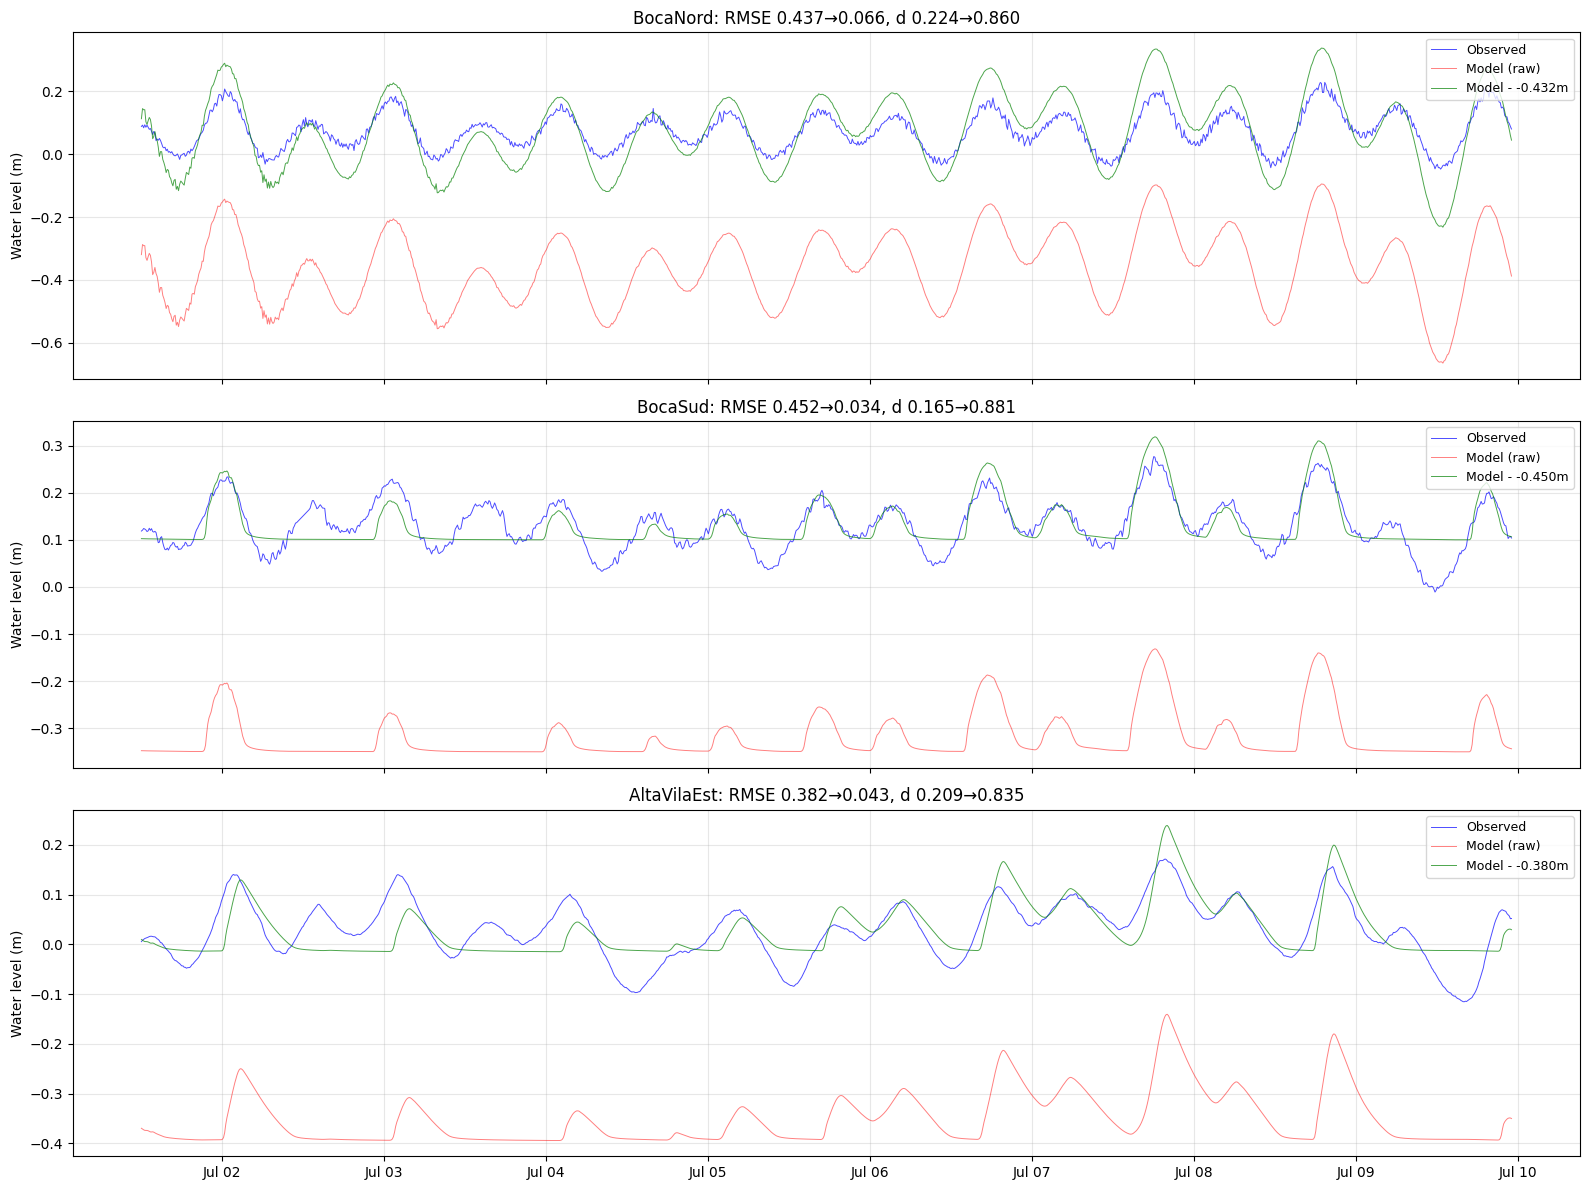

In [23]:
# Apply offset correction (use per-station bias) and re-evaluate
from sklearn.metrics import mean_squared_error

def willmott_d(obs, mod):
    obs, mod = np.asarray(obs), np.asarray(mod)
    o_bar = obs.mean()
    return 1 - np.sum((mod - obs) ** 2) / np.sum((np.abs(mod - o_bar) + np.abs(obs - o_bar)) ** 2)

fig, axes = plt.subplots(len(comparisons), 1, figsize=(16, 4 * len(comparisons)), sharex=True)
if len(comparisons) == 1:
    axes = [axes]

print(f'{"Station":<12} {"RMSE_raw":>10} {"RMSE_corr":>10} {"d_raw":>8} {"d_corr":>8} {"offset":>10}')
print('-' * 62)

for ax, (name, df) in zip(axes, comparisons.items()):
    offset = biases[name]
    df = df.copy()
    df['wl_model_corr'] = df['wl_model'] - offset
    
    rmse_raw = np.sqrt(mean_squared_error(df['wl_obs'], df['wl_model']))
    rmse_corr = np.sqrt(mean_squared_error(df['wl_obs'], df['wl_model_corr']))
    d_raw = willmott_d(df['wl_obs'], df['wl_model'])
    d_corr = willmott_d(df['wl_obs'], df['wl_model_corr'])
    print(f'{name:<12} {rmse_raw:10.4f} {rmse_corr:10.4f} {d_raw:8.3f} {d_corr:8.3f} {offset:+10.4f}')
    
    ax.plot(df.index, df['wl_obs'], 'b-', linewidth=0.7, alpha=0.7, label='Observed')
    ax.plot(df.index, df['wl_model'], 'r-', linewidth=0.7, alpha=0.5, label='Model (raw)')
    ax.plot(df.index, df['wl_model_corr'], 'g-', linewidth=0.7, alpha=0.7,
            label=f'Model - {offset:+.3f}m')
    ax.set_title(f'{name}: RMSE {rmse_raw:.3f}→{rmse_corr:.3f}, d {d_raw:.3f}→{d_corr:.3f}')
    ax.set_ylabel('Water level (m)')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
fig.tight_layout()
plt.savefig(str(figures_dir / 'diag_bias_correction.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Drying check at BS and AE

Extract water depth at each station. If it approaches zero, the cell is drying and the WL signal will be distorted.

Station             x        y      bed  min_depth mean_depth
------------------------------------------------------------
BocaNord      12.4572  37.9053   -0.691     0.0261     0.3342
BocaSud       12.4490  37.8470   -0.351     0.0012     0.0344
AltaVilaEst   12.4470  37.8901   -0.396     0.0016     0.0540


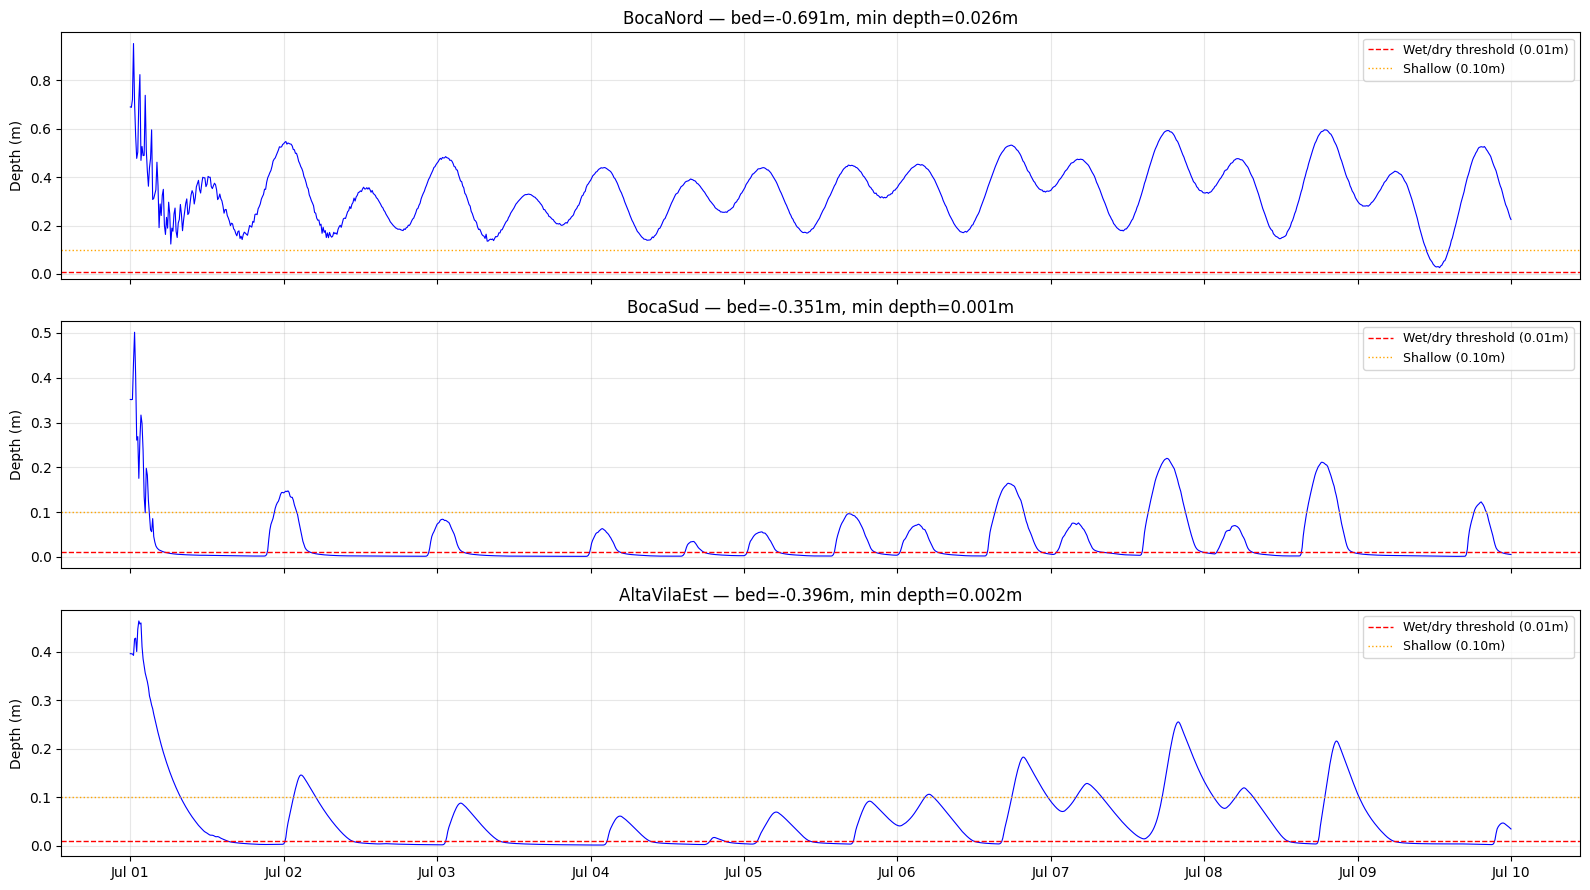

In [24]:
# Water depth at observation stations
if 'waterdepth' in ds_his:
    wdepth_var = 'waterdepth'
elif 'water_depth' in ds_his:
    wdepth_var = 'water_depth'
else:
    # Try to compute: waterlevel - bedlevel
    wdepth_var = None

fig, axes = plt.subplots(len(idx), 1, figsize=(16, 3 * len(idx)), sharex=True)
if len(idx) == 1:
    axes = [axes]

print(f'{"Station":<12} {"x":>8} {"y":>8} {"bed":>8} {"min_depth":>10} {"mean_depth":>10}')
print('-' * 60)

for ax, (name, station_idx) in zip(axes, idx.items()):
    if station_idx is None:
        continue
    x = float(ds_his.station_x_coordinate.isel(station=station_idx))
    y = float(ds_his.station_y_coordinate.isel(station=station_idx))
    bed = float(ds_his.bedlevel.isel(station=station_idx)) if 'bedlevel' in ds_his else np.nan
    
    if wdepth_var:
        depth = ds_his[wdepth_var].isel(station=station_idx).to_pandas()
    else:
        wl = ds_his.waterlevel.isel(station=station_idx).to_pandas()
        depth = wl - bed
    
    print(f'{name:<12} {x:8.4f} {y:8.4f} {bed:8.3f} {depth.min():10.4f} {depth.mean():10.4f}')
    
    ax.plot(depth.index, depth.values, 'b-', linewidth=0.8)
    ax.axhline(0.01, color='red', linestyle='--', linewidth=1, label='Wet/dry threshold (0.01m)')
    ax.axhline(0.10, color='orange', linestyle=':', linewidth=1, label='Shallow (0.10m)')
    ax.set_title(f'{name} — bed={bed:.3f}m, min depth={depth.min():.3f}m')
    ax.set_ylabel('Depth (m)')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
fig.tight_layout()
plt.savefig(str(figures_dir / 'diag_drying_check.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Load map.nc and find deeper central cells

We load the spatial output with xugrid, find the bed level map, and pick candidate cells in the central lagoon at deeper depths.

In [13]:
# Open map file with xugrid (lazy loading via dask)
uds = xu.open_dataset(str(map_file), chunks={'time': 50})
print(f'Dimensions: {dict(uds.sizes)}')
print(f'Number of faces: {uds.grid.face_coordinates[0].size}')
print(f'Number of layers: {uds.sizes.get("mesh2d_nLayers", 0)}')

Dimensions: {'mesh2d_nNodes': 21188, 'mesh2d_nFaces': 25207, 'mesh2d_nMax_face_nodes': 5, 'mesh2d_nEdges': 46404, 'time': 433, 'mesh2d_nLayers': 10, 'mesh2d_nInterfaces': 11}
Number of faces: 2
Number of layers: 10


n_faces: 25207
Face coords range:
  Lon: 11.9650 to 12.5578
  Lat: 37.7003 to 38.0629
Bed level range: -728.69 to 10.00 m
Faces in lagoon box: 3886


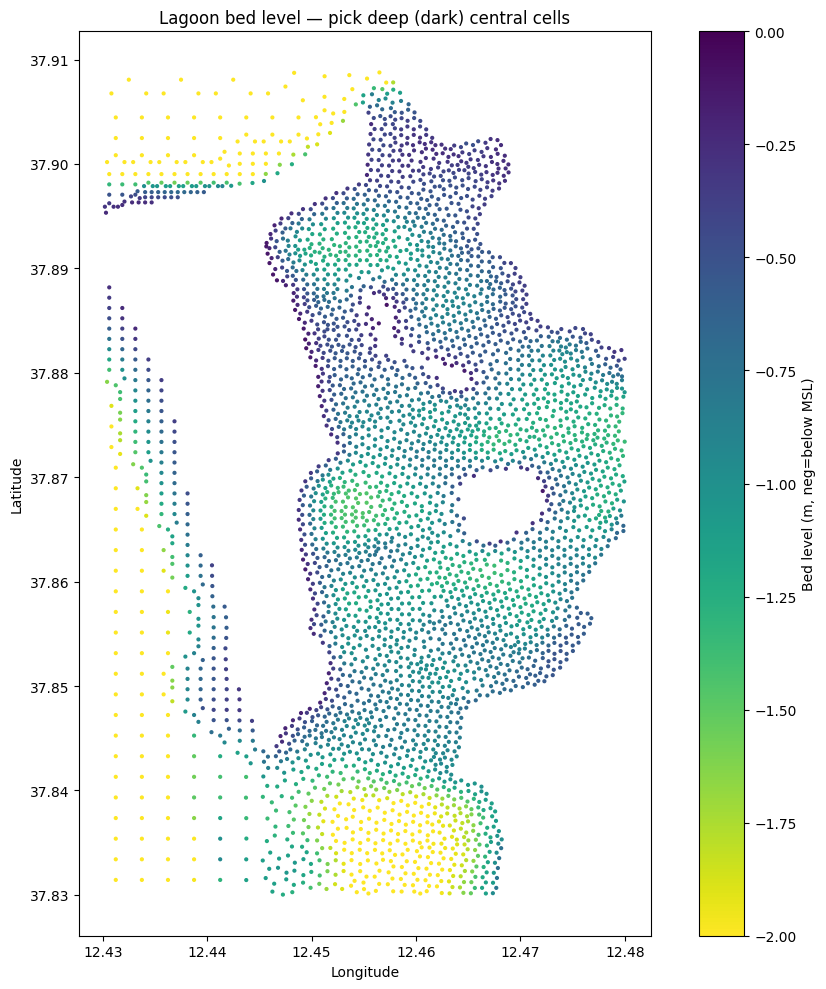

In [14]:
# Get face centers and bed level
# xugrid face_coordinates returns a tuple (x, y). Get them via the grid object
face_coords = uds.grid.face_coordinates  # shape (n_faces, 2)
face_x = face_coords[:, 0] if face_coords.ndim == 2 else uds.grid.face_x
face_y = face_coords[:, 1] if face_coords.ndim == 2 else uds.grid.face_y
face_x = np.asarray(face_x)
face_y = np.asarray(face_y)

bl = uds["mesh2d_flowelem_bl"].values  # bed level at face centers (positive up)

print(f"n_faces: {len(face_x)}")
print(f"Face coords range:")
print(f"  Lon: {face_x.min():.4f} to {face_x.max():.4f}")
print(f"  Lat: {face_y.min():.4f} to {face_y.max():.4f}")
print(f"Bed level range: {bl.min():.2f} to {bl.max():.2f} m")

# Filter faces inside the lagoon (approximate box)
lagoon_mask = ((face_x > 12.43) & (face_x < 12.48) &
               (face_y > 37.83) & (face_y < 37.91))
print(f"Faces in lagoon box: {lagoon_mask.sum()}")

# Plot bed level inside the lagoon to find central deep areas
fig, ax = plt.subplots(figsize=(10, 10))
sc = ax.scatter(face_x[lagoon_mask], face_y[lagoon_mask], c=bl[lagoon_mask],
                 cmap="viridis_r", s=4, vmin=-2, vmax=0)
plt.colorbar(sc, ax=ax, label="Bed level (m, neg=below MSL)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Lagoon bed level — pick deep (dark) central cells")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(str(figures_dir / "diag_lagoon_bathy.png"), dpi=150)
plt.show()

In [15]:
# Define candidate central points (adjust based on bed level plot)
targets = [
    ("C1_Central", 12.455, 37.870),     # near Mozia
    ("C2_NorthCenter", 12.46, 37.89),  # between Mozia and BocaNord
    ("C3_SouthCenter", 12.458, 37.855),  # between Mozia and BocaSud
]

# Find nearest face index for each target
def nearest_face(lon, lat, fx, fy):
    dist = (fx - lon) ** 2 + (fy - lat) ** 2
    return int(np.argmin(dist))

central_indices = {}
print(f"{"Point":<18} {"lon_target":>11} {"lat_target":>11} {"lon_actual":>11} {"lat_actual":>11} {"bed_lvl":>10}")
print("-" * 80)
for name, lon, lat in targets:
    idx_face = nearest_face(lon, lat, face_x, face_y)
    central_indices[name] = idx_face
    print(f"{name:<18} {lon:11.4f} {lat:11.4f} {face_x[idx_face]:11.4f} {face_y[idx_face]:11.4f} {bl[idx_face]:10.3f}")


Point               lon_target  lat_target  lon_actual  lat_actual    bed_lvl
--------------------------------------------------------------------------------
C1_Central             12.4550     37.8700     12.4550     37.8705     -1.228
C2_NorthCenter         12.4600     37.8900     12.4599     37.8898     -0.973
C3_SouthCenter         12.4580     37.8550     12.4577     37.8552     -0.976


## 5. Extract time series at central points and analyze 3D vertical structure

In [16]:
# Extract time series for each central point
# These operations load only the needed cells (dask lazy evaluation)
central_data = {}
for name, i in central_indices.items():
    print(f'Loading {name} (face {i})...')
    central_data[name] = {
        's1': uds['mesh2d_s1'].isel(mesh2d_nFaces=i).compute(),        # water level
        'depth': uds['mesh2d_waterdepth'].isel(mesh2d_nFaces=i).compute(),
        'ucx': uds['mesh2d_ucx'].isel(mesh2d_nFaces=i).compute(),      # (time, layer)
        'ucy': uds['mesh2d_ucy'].isel(mesh2d_nFaces=i).compute(),
        'sa1': uds['mesh2d_sa1'].isel(mesh2d_nFaces=i).compute(),      # salinity
        'tem1': uds['mesh2d_tem1'].isel(mesh2d_nFaces=i).compute(),    # temperature
        'bed': bl[i],
    }
    d = central_data[name]
    print(f'  mean depth: {float(d["depth"].mean()):.2f}m, '
          f'min depth: {float(d["depth"].min()):.3f}m')
print('Done.')

Loading C1_Central (face 23775)...
  mean depth: 0.87m, min depth: 0.674m
Loading C2_NorthCenter (face 23448)...
  mean depth: 0.62m, min depth: 0.503m
Loading C3_SouthCenter (face 22997)...
  mean depth: 0.62m, min depth: 0.444m
Done.


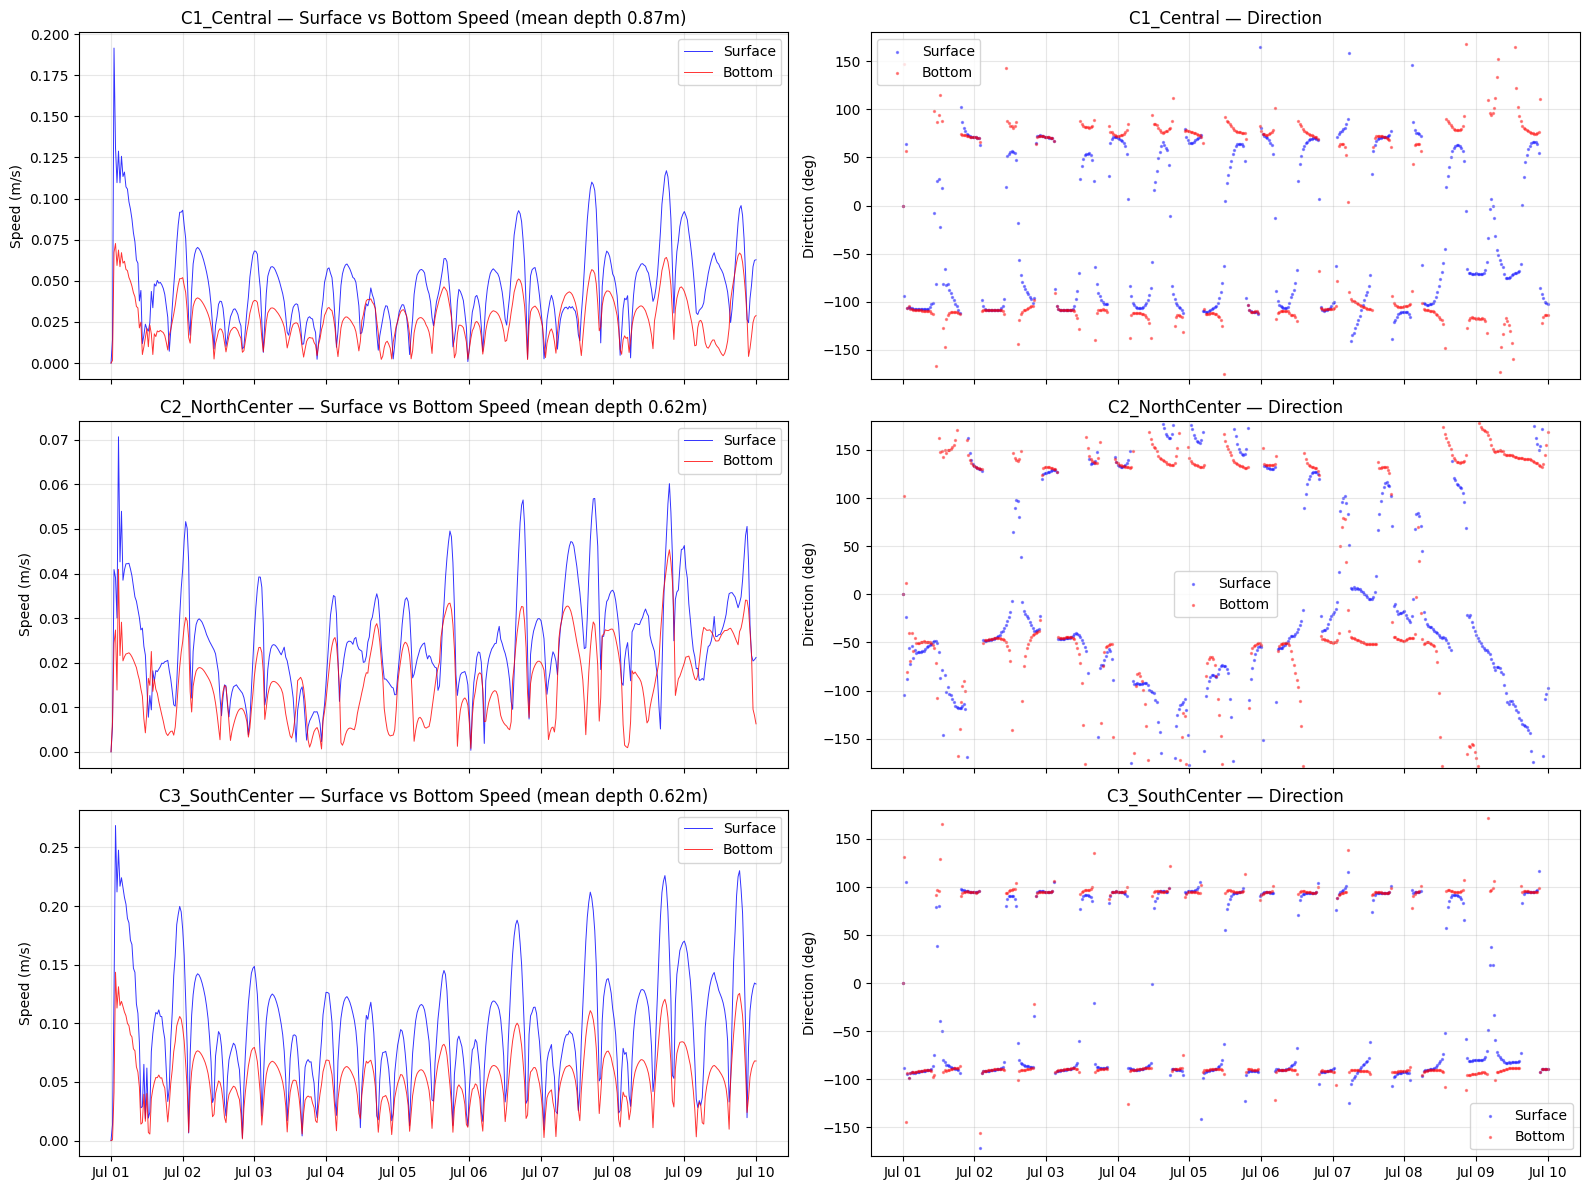


=== VERTICAL SHEAR STATISTICS ===
C1_Central: mean surf speed 0.047, bot 0.027 m/s, ratio 1.73, mean |dir diff|=27.7°
C2_NorthCenter: mean surf speed 0.025, bot 0.016 m/s, ratio 1.55, mean |dir diff|=43.9°
C3_SouthCenter: mean surf speed 0.098, bot 0.054 m/s, ratio 1.84, mean |dir diff|=9.8°


In [17]:
# Plot 3D vertical structure: surface vs bottom velocity at each central point
fig, axes = plt.subplots(len(central_data), 2, figsize=(16, 4 * len(central_data)), sharex=True)
if len(central_data) == 1:
    axes = axes.reshape(1, -1)

for row, (name, d) in enumerate(central_data.items()):
    ucx = d['ucx'].values  # (time, layer)
    ucy = d['ucy'].values
    t = d['ucx'].time.values
    
    # Surface = top layer (index -1), bottom = first layer (index 0)
    u_surf, v_surf = ucx[:, -1], ucy[:, -1]
    u_bot, v_bot = ucx[:, 0], ucy[:, 0]
    speed_surf = np.sqrt(u_surf**2 + v_surf**2)
    speed_bot = np.sqrt(u_bot**2 + v_bot**2)
    
    # Speed comparison
    ax = axes[row, 0]
    ax.plot(t, speed_surf, 'b-', linewidth=0.7, alpha=0.8, label='Surface')
    ax.plot(t, speed_bot, 'r-', linewidth=0.7, alpha=0.8, label='Bottom')
    ax.set_ylabel('Speed (m/s)')
    ax.set_title(f'{name} — Surface vs Bottom Speed (mean depth {float(d["depth"].mean()):.2f}m)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Direction (math convention, atan2)
    ax = axes[row, 1]
    dir_surf = np.degrees(np.arctan2(v_surf, u_surf))
    dir_bot = np.degrees(np.arctan2(v_bot, u_bot))
    ax.scatter(t, dir_surf, c='blue', s=2, alpha=0.4, label='Surface')
    ax.scatter(t, dir_bot, c='red', s=2, alpha=0.4, label='Bottom')
    ax.set_ylabel('Direction (deg)')
    ax.set_title(f'{name} — Direction')
    ax.set_ylim(-180, 180)
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[-1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
fig.tight_layout()
plt.savefig(str(figures_dir / 'diag_central_3D_structure.png'), dpi=150, bbox_inches='tight')
plt.show()

# Shear statistics
print('\n=== VERTICAL SHEAR STATISTICS ===')
for name, d in central_data.items():
    ucx, ucy = d['ucx'].values, d['ucy'].values
    speed_surf = np.sqrt(ucx[:, -1]**2 + ucy[:, -1]**2)
    speed_bot = np.sqrt(ucx[:, 0]**2 + ucy[:, 0]**2)
    # Direction difference (modulo 360)
    dir_surf = np.degrees(np.arctan2(ucy[:, -1], ucx[:, -1]))
    dir_bot = np.degrees(np.arctan2(ucy[:, 0], ucx[:, 0]))
    ddir = ((dir_surf - dir_bot + 180) % 360) - 180  # wrap to [-180, 180]
    print(f'{name}: mean surf speed {speed_surf.mean():.3f}, bot {speed_bot.mean():.3f} m/s, '
          f'ratio {speed_surf.mean()/max(speed_bot.mean(), 1e-6):.2f}, '
          f'mean |dir diff|={np.abs(ddir).mean():.1f}°')

## 6. Hovmöller diagrams (depth-time) for one central point

Visualize velocity, salinity, and temperature evolution across all sigma layers.

Analyzing C1_Central (deepest central point)


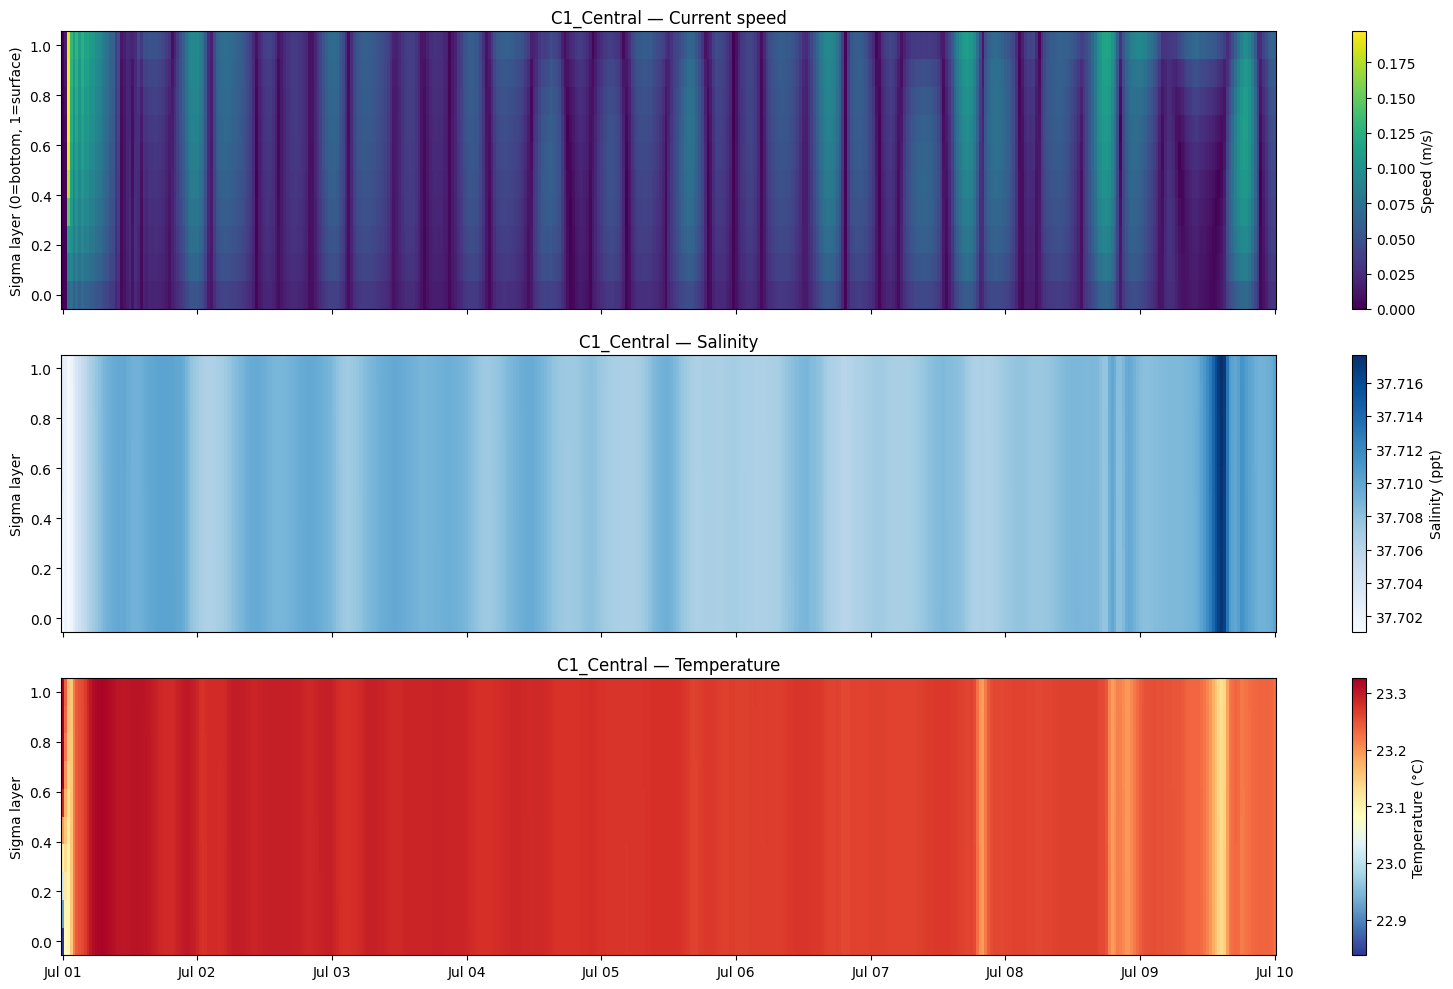

In [18]:
# Pick the deepest central point for detailed vertical analysis
deepest_name = max(central_data, key=lambda k: float(central_data[k]['depth'].mean()))
d = central_data[deepest_name]
print(f'Analyzing {deepest_name} (deepest central point)')

t = d['ucx'].time.values
n_layers = d['ucx'].shape[-1]
layer_norm = np.linspace(0, 1, n_layers)  # sigma: 0=bottom, 1=surface

speed = np.sqrt(d['ucx'].values**2 + d['ucy'].values**2)  # (time, layer)
sal = d['sa1'].values
tem = d['tem1'].values

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Speed
im = axes[0].pcolormesh(t, layer_norm, speed.T, cmap='viridis', shading='auto')
plt.colorbar(im, ax=axes[0], label='Speed (m/s)')
axes[0].set_ylabel('Sigma layer (0=bottom, 1=surface)')
axes[0].set_title(f'{deepest_name} — Current speed')

# Salinity
im = axes[1].pcolormesh(t, layer_norm, sal.T, cmap='cmo.haline' if 'cmo' in dir() else 'Blues', shading='auto')
plt.colorbar(im, ax=axes[1], label='Salinity (ppt)')
axes[1].set_ylabel('Sigma layer')
axes[1].set_title(f'{deepest_name} — Salinity')

# Temperature
im = axes[2].pcolormesh(t, layer_norm, tem.T, cmap='RdYlBu_r', shading='auto')
plt.colorbar(im, ax=axes[2], label='Temperature (°C)')
axes[2].set_ylabel('Sigma layer')
axes[2].set_title(f'{deepest_name} — Temperature')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

fig.tight_layout()
plt.savefig(str(figures_dir / 'diag_hovmoller.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Find always-wet alternative cells for BN, BS, AE

For stations affected by drying or near-margin effects, find a nearby cell that stays wet 
throughout the simulation and re-do the WL comparison using data extracted from map.nc.

In [25]:
# Original station coordinates (from his.nc)
station_coords = {}
for name, i in idx.items():
    if i is None:
        continue
    x = float(ds_his.station_x_coordinate.isel(station=i))
    y = float(ds_his.station_y_coordinate.isel(station=i))
    station_coords[name] = (x, y)
    print(f'{name}: ({x:.4f}, {y:.4f})')

# Compute min depth across time per face (used to identify always-wet cells)
print('\nComputing min depth per face (this takes ~30s)...')
min_depth_per_face = uds['mesh2d_waterdepth'].min(dim='time').compute().values
print(f'Done. Range: {min_depth_per_face.min():.3f} to {min_depth_per_face.max():.3f} m')
print(f'Faces with min depth > 0.15 m: {(min_depth_per_face > 0.15).sum()} / {len(min_depth_per_face)}')

BocaNord: (12.4572, 37.9053)
BocaSud: (12.4490, 37.8470)
AltaVilaEst: (12.4470, 37.8901)

Computing min depth per face (this takes ~30s)...
Done. Range: 0.000 to 728.031 m
Faces with min depth > 0.15 m: 18333 / 25207


In [26]:
# Find nearest always-wet cell within a search radius for each station
MIN_DEPTH_THRESHOLD = 0.15  # m — cell must have at least this min depth
SEARCH_RADIUS_DEG = 0.005    # ~500m around the station

replacement_idx = {}
print(f'{"Station":<14} {"orig_xy":<22} {"new_xy":<22} {"dist_m":>8} {"min_depth":>10} {"bed":>8}')
print('-' * 90)
for name, (x0, y0) in station_coords.items():
    dist2 = (face_x - x0) ** 2 + (face_y - y0) ** 2
    candidates = np.where((dist2 < SEARCH_RADIUS_DEG ** 2) &
                           (min_depth_per_face > MIN_DEPTH_THRESHOLD))[0]
    if len(candidates) == 0:
        print(f'{name:<14} NO always-wet cell within {SEARCH_RADIUS_DEG*111000:.0f}m')
        replacement_idx[name] = None
        continue
    # Among always-wet candidates, pick the deepest (most negative bed)
    deepest = candidates[np.argmin(bl[candidates])]
    nx, ny = face_x[deepest], face_y[deepest]
    d_m = np.sqrt(dist2[deepest]) * 111000 * np.cos(np.radians(y0))
    replacement_idx[name] = deepest
    orig = f'({x0:.4f},{y0:.4f})'
    new = f'({nx:.4f},{ny:.4f})'
    print(f'{name:<14} {orig:<22} {new:<22} {d_m:>8.1f} {min_depth_per_face[deepest]:>10.3f} {bl[deepest]:>8.3f}')

Station        orig_xy                new_xy                   dist_m  min_depth      bed
------------------------------------------------------------------------------------------
BocaNord       (12.4572,37.9053)      (12.4536,37.9085)         425.4      4.321   -4.989
BocaSud        (12.4490,37.8470)      (12.4497,37.8422)         420.1      0.499   -1.143
AltaVilaEst    (12.4470,37.8901)      (12.4517,37.8918)         429.9      0.826   -1.299


Station         RMSE_orig   RMSE_new   d_orig    d_new   bias_new
------------------------------------------------------------------------
BocaNord           0.0656     0.0663    0.860    0.857    -0.4329
BocaSud            0.0338     0.0572    0.881    0.860    -0.5059
AltaVilaEst        0.0432     0.0418    0.835    0.871    -0.3891


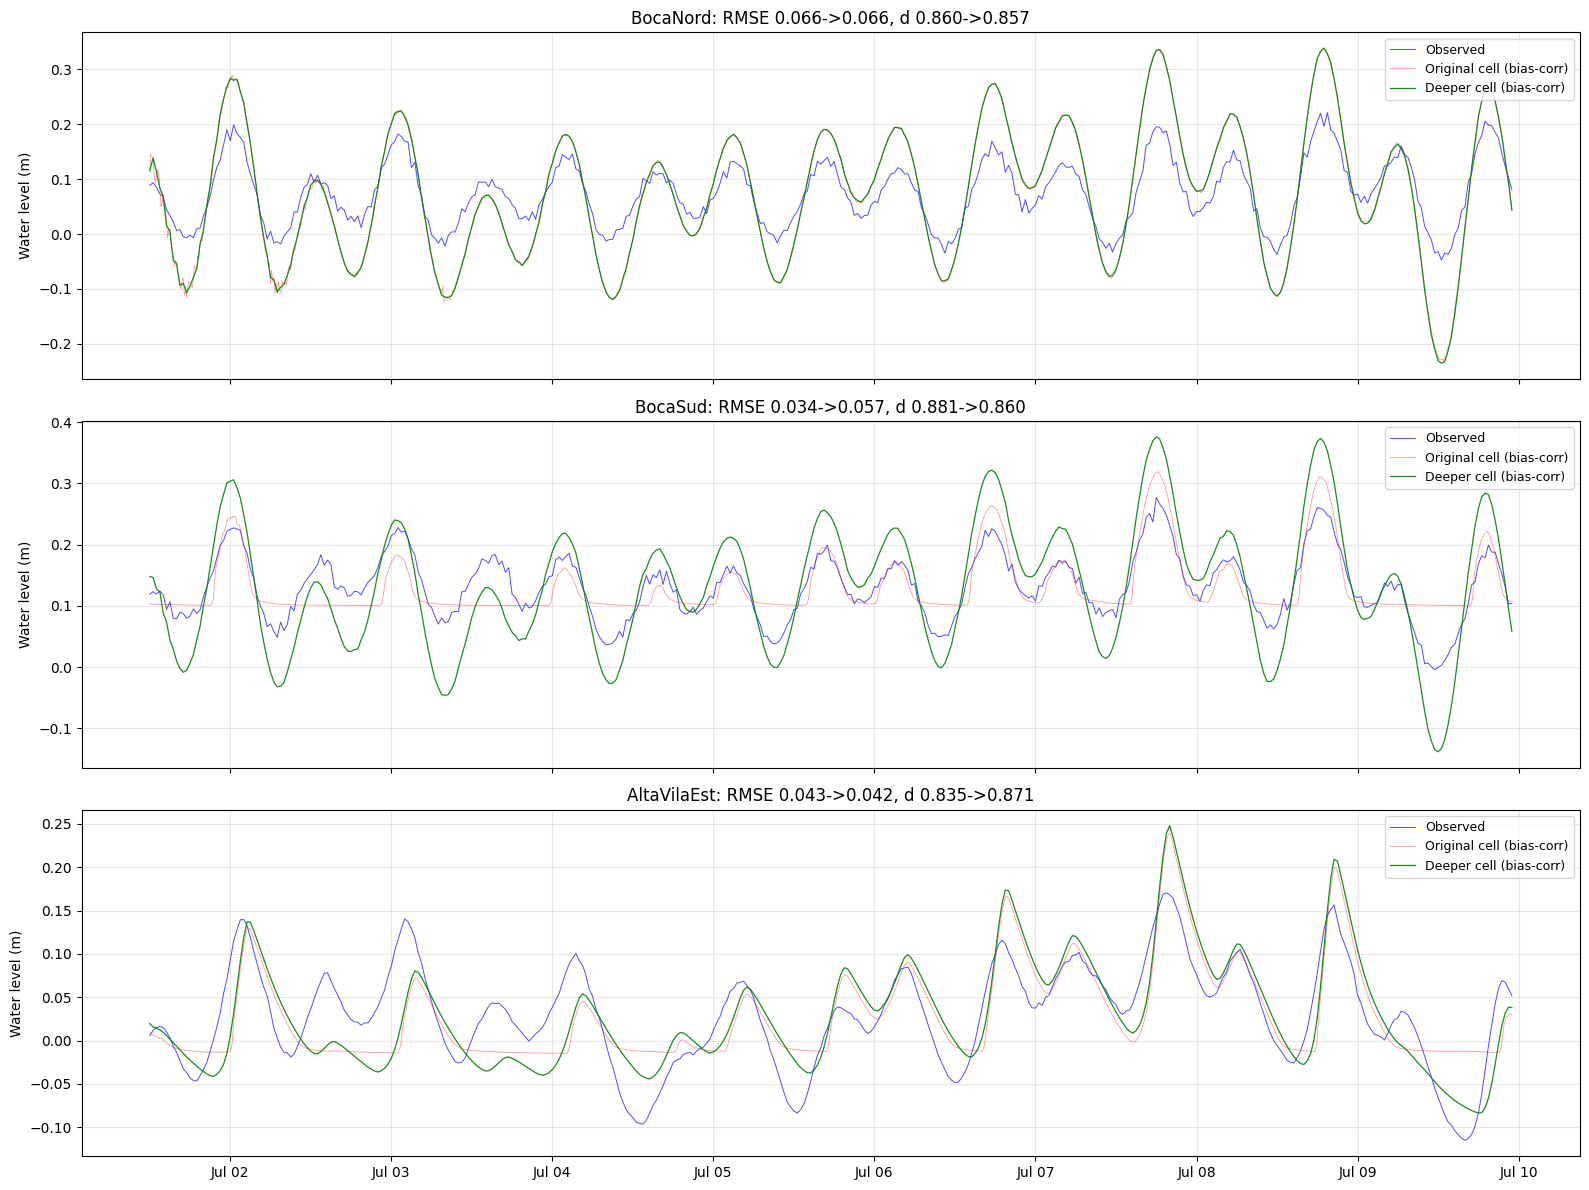

In [27]:
# Extract water level at replacement cells and compare with observations
from sklearn.metrics import mean_squared_error

fig, axes = plt.subplots(len(station_coords), 1, figsize=(16, 4 * len(station_coords)), sharex=True)
if len(station_coords) == 1:
    axes = [axes]

print(f'{"Station":<14} {"RMSE_orig":>10} {"RMSE_new":>10} {"d_orig":>8} {"d_new":>8} {"bias_new":>10}')
print('-' * 72)
new_comparisons = {}
for ax, (name, face_i) in zip(axes, replacement_idx.items()):
    if face_i is None:
        ax.set_visible(False)
        continue
    wl_new = uds['mesh2d_s1'].isel(mesh2d_nFaces=face_i).compute().to_pandas()
    wl_new.name = 'wl_model_new'

    obs = pd.read_csv(str(processed_dir / obs_files[name]), index_col=0, parse_dates=True)
    obs.columns = ['wl_obs']

    df = pd.concat([wl_new, obs['wl_obs']], axis=1).dropna()
    df = df[df.index >= df.index[0] + pd.Timedelta(hours=12)].copy()

    bias = (df['wl_model_new'] - df['wl_obs']).mean()
    df['wl_model_corr'] = df['wl_model_new'] - bias
    new_comparisons[name] = df

    # Metrics: compare to original-cell (also bias-corrected)
    orig = comparisons[name]
    bias_o = (orig['wl_model'] - orig['wl_obs']).mean()
    orig_corr = orig['wl_model'] - bias_o
    rmse_orig = np.sqrt(mean_squared_error(orig['wl_obs'], orig_corr))
    rmse_new = np.sqrt(mean_squared_error(df['wl_obs'], df['wl_model_corr']))
    d_orig = willmott_d(orig['wl_obs'], orig_corr)
    d_new = willmott_d(df['wl_obs'], df['wl_model_corr'])
    print(f'{name:<14} {rmse_orig:>10.4f} {rmse_new:>10.4f} {d_orig:>8.3f} {d_new:>8.3f} {bias:>+10.4f}')

    ax.plot(df.index, df['wl_obs'], 'b-', linewidth=0.7, alpha=0.7, label='Observed')
    ax.plot(orig.index, orig_corr, 'r-', linewidth=0.6, alpha=0.4, label='Original cell (bias-corr)')
    ax.plot(df.index, df['wl_model_corr'], 'g-', linewidth=0.9, alpha=0.9, label='Deeper cell (bias-corr)')
    ax.set_title(f'{name}: RMSE {rmse_orig:.3f}->{rmse_new:.3f}, d {d_orig:.3f}->{d_new:.3f}')
    ax.set_ylabel('Water level (m)')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
fig.tight_layout()
plt.savefig(str(figures_dir / 'diag_replacement_cells.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary of diagnostics

Key findings from this analysis will guide next steps:

| Issue | Finding | Fix |
|-------|---------|-----|
| Datum bias | See Section 2 output | Apply offset to `waterlevelbnd_constant_*.bc` |
| Drying at BS/AE | See Section 3 plots | Relocate obs points or refine mesh near margins |
| 3D vertical structure | See Section 5 | Use central points — AltaVilaEst too shallow |